In [ ]:
!pip install diffusers transformers accelerate

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

# select model
model_id = "runwayml/stable-diffusion-v1-5"

# load pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float32)

# use CPU
device = "cpu"
pipe = pipe.to(device)

print("Model was loaded")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model was loaded


starting of generation...


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:897: FutureWarning: `callback` is deprecated and will be removed in version 1.0.0. Passing `callback` as an input argument to `__call__` is deprecated, consider using `callback_on_step_end`
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:903: FutureWarning: `callback_steps` is deprecated and will be removed in version 1.0.0. Passing `callback_steps` as an input argument to `__call__` is deprecated, consider using `callback_on_step_end`
  deprecate(


  0%|          | 0/20 [00:00<?, ?it/s]

Step 1. Current value of noise: -0.0160
Step 2. Current value of noise: -0.0196
Step 3. Current value of noise: -0.0246
Step 4. Current value of noise: -0.0292
Step 5. Current value of noise: -0.0376
Step 6. Current value of noise: -0.0409
Step 7. Current value of noise: -0.0495
Step 8. Current value of noise: -0.0549
Step 9. Current value of noise: -0.0622
Step 10. Current value of noise: -0.0687
Step 11. Current value of noise: -0.0754
Step 12. Current value of noise: -0.0817
Step 13. Current value of noise: -0.0878
Step 14. Current value of noise: -0.0933
Step 15. Current value of noise: -0.0983
Step 16. Current value of noise: -0.1027
Step 17. Current value of noise: -0.1064
Step 18. Current value of noise: -0.1095
Step 19. Current value of noise: -0.1118
Step 20. Current value of noise: -0.1119


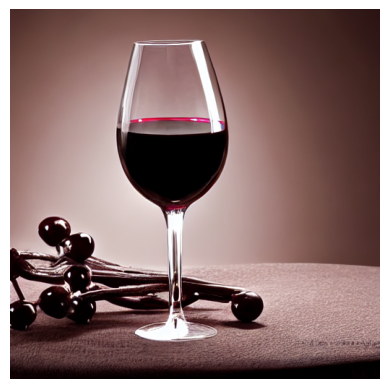

Finished!


In [ ]:
import matplotlib.pyplot as plt

# our prompt for CLIP
prompt = "glass of red wine on a wrought iron table, studio lighting, high resolution"

# function-callback which call in each step of scheduler
def latents_callback(step, timestamp, latents):
  print(f"Step {step}. Current value of noise: {latents.mean().item():.4f}")

# generation
print("starting of generation...")
image = pipe(
    prompt=prompt,
    num_inference_steps=20, # num_inference_steps - scheduler for U-Net
    guidance_scale=7.5,
    callback=latents_callback,
    callback_steps=1 # call 'latents_callback' each step
).images[0]

# save image
image.save("red_wine.png")

plt.imshow(image)
plt.axis("off")
plt.show()

print("Finished!")